In [ ]:
#only if opendatasets was never installed before
#!pip install opendatasets

In [2]:
import opendatasets as od
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [7]:
def data_from_kaggle(dataset):
    """
    Download a Kaggle dataset using opendatasets and return the loaded DataFrame. Works with only one csv
    
    Args:
        dataset: Kaggle dataset URL.
    
    Returns:
        df (pd.DataFrame): CSV file found in the dataset folder, converted to pd.DataFrame
    """
    data_dir =  od.download(dataset)
    if data_dir is None:
        # Extract folder name from URL
        folder_name = dataset.split('/')[-1]
        data_dir = f'./{folder_name}'
    file = os.listdir(data_dir)
    csv_path = os.path.join(data_dir, file[0])
    df = pd.read_csv(csv_path)
    return df
    

In [8]:
imdb = data_from_kaggle(dataset)

Skipping, found downloaded files in ".\imdb-dataset-of-top-1000-movies-and-tv-shows" (use force=True to force download)


In [9]:
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [12]:
#documentation not done
def fill(df, column, median = True):
    """
    Fills nan values of a certain column of a dataframe. Possibility to fill with median or mean
    
    Args:
        df (pd.DataFrame): df we're working on
        column(str) : column name
    
    Returns:
        df (pd.DataFrame): CSV file found in the dataset folder, converted to pd.DataFrame
    """
    
    if median:
        temp = df[column].median()
    else:
        temp = df[column].mean()
    df[column] = df[column].fillna(temp)
    return df

In [ ]:
#let's have a look on our dataset

In [10]:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

Cleaning process

In [13]:
#Dropping unneccessary columns and renaming the ambigious ones

In [14]:
imdb_cleaned = imdb.drop(columns = ['Star2', 'Star3', 'Star4'])

In [15]:
imdb_cleaned = imdb_cleaned.rename({'Star1': 'Main star'}, axis = 1)

In [16]:
imdb_cleaned = imdb_cleaned.rename({'Gross': 'Revenue(millions)'}, axis = 1) #we'll change revenue to millions later

In [17]:
#make a function that gives you main info about df, like length, columns, datatypes, 
#if there are any duplicates(with possibility to remove them), which columns contain null values and how much in percentage

In [18]:
#Dropping complete duplicates, if any

In [19]:
imdb_cleaned = imdb_cleaned.drop_duplicates()

In [20]:
#handling null values

In [21]:
#looking at the null values and deciding how to handle them

In [22]:
imdb_cleaned.isnull().sum()*100/len(imdb_cleaned)

#we have only three columns that have null values and non of them depasses 20% so 

Poster_Link           0.0
Series_Title          0.0
Released_Year         0.0
Certificate          10.1
Runtime               0.0
Genre                 0.0
IMDB_Rating           0.0
Overview              0.0
Meta_score           15.7
Director              0.0
Main star             0.0
No_of_Votes           0.0
Revenue(millions)    16.9
dtype: float64

In [23]:
imdb_cleaned["Certificate"].unique()

array(['A', 'UA', 'U', 'PG-13', 'R', nan, 'PG', 'G', 'Passed', 'TV-14',
       '16', 'TV-MA', 'Unrated', 'GP', 'Approved', 'TV-PG', 'U/A'],
      dtype=object)

In [24]:
#among all the unique categories we can see "unrated" which is essentially the same as nan, so we'll fill it as it follows

In [25]:
imdb_cleaned['Certificate'] = imdb_cleaned['Certificate'].fillna('Unrated')

In [26]:
#sanity check
imdb_cleaned['Certificate'].isnull().sum()

0

In [27]:
#we want to fill Meta score and Gross. Both values are numerical and we have to look if there are any outliers to
#decide what method to use

<Axes: xlabel='Meta_score'>

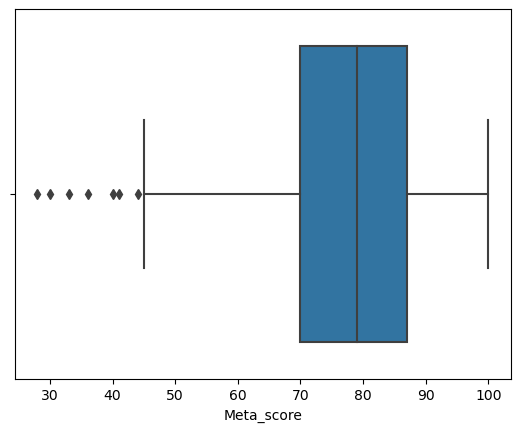

In [28]:
sns.boxplot(x = imdb_cleaned['Meta_score'])

In [29]:
#we have some lower outliers so it would be better to use median to fill NaN values

In [30]:
fill(imdb_cleaned,"Meta_score", median = True )

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Main star,No_of_Votes,Revenue(millions)
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,Unrated,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,26471,NaN


In [32]:
imdb_cleaned["Revenue(millions)"].isnull().sum()

169

In [33]:
imdb_cleaned['Revenue(millions)'] = imdb_cleaned['Revenue(millions)'].str.replace(',', '').astype(float)

In [34]:
imdb_cleaned['Revenue(millions)'] = imdb_cleaned['Revenue(millions)']/1e6

<Axes: xlabel='Revenue(millions)'>

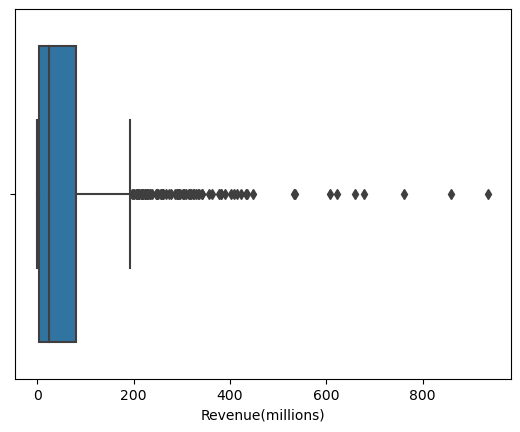

In [35]:
sns.boxplot(x = imdb_cleaned['Revenue(millions)'])

In [36]:
#plenty of outliers let's use median as well

In [37]:
fill(imdb_cleaned,"Revenue(millions)", median = True )

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Main star,No_of_Votes,Revenue(millions)
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,2343110,28.341469
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,1620367,134.966411
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,2303232,534.858444
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,1129952,57.300000
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,689845,4.360000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,166544,23.530892
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,34075,23.530892
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,43374,30.500000
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,Unrated,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,26471,23.530892


In [38]:
imdb_cleaned['Genre'] = imdb_cleaned['Genre'].str.split(",").str[0].str.strip()

In [39]:
#Checking for datatypes

In [40]:
imdb_cleaned.dtypes

Poster_Link           object
Series_Title          object
Released_Year         object
Certificate           object
Runtime               object
Genre                 object
IMDB_Rating          float64
Overview              object
Meta_score           float64
Director              object
Main star             object
No_of_Votes            int64
Revenue(millions)    float64
dtype: object

In [41]:
#released year should be an int, runtime should be an int , Revenue should be an integer

In [42]:
#Let's convert Runtime into an int. For this we first transform the data

In [43]:
imdb_cleaned['Runtime'] = imdb_cleaned['Runtime'].str.split(' ').str[0].str.strip()

In [44]:
#We want to change a type in released year but there is a value PG that blocks us from doing that, let's handle that

In [45]:
imdb_cleaned[imdb_cleaned['Released_Year'] == 'PG']

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Main star,No_of_Votes,Revenue(millions)
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140,Adventure,7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,269197,173.837933


In [46]:
#since this is the only row missing the information, and since the information is publicly known in the internet,
#we just change the value by hand. The film was released in 1995

In [47]:
imdb_cleaned.loc[imdb_cleaned['Released_Year'] == 'PG', 'Released_Year'] = 1995

In [48]:
imdb_cleaned = imdb_cleaned.astype({'Released_Year' : 'int', 'Runtime': 'int'})

In [51]:
df = imdb_cleaned

In [49]:
#EXPLORATORY DATA ANALYSIS

In this part we will try to answer quite a few questions about this dataset

How many movies are in the dataset?
What are the different genres present in the dataset?
How many unique directors are listed in the dataset?
What is the average IMDb rating of all movies?
What is the highest-rated movie in the dataset?
What is the oldest movie in the dataset?
How many movies were released before the year 2000?
What is the most common movie certificate in the dataset?
Which director(s) have the most movies in the dataset?

How many movies are in the dataset?

In [52]:
print(f"There are {len(df)} movies in this dataset")

There are 1000 movies in this dataset


What are the different genres present in the dataset?

In [62]:
res = ', '.join(df['Genre'].unique())
print(f"There are {len(df['Genre'].unique())} unique genres.\nHere is the list of all of them: {res}")


There are 14 unique genres.
Here is the list of all of them: Drama, Crime, Action, Biography, Western, Comedy, Adventure, Animation, Horror, Mystery, Film-Noir, Fantasy, Family, Thriller


How many unique directors are listed in the dataset? 

In [64]:
print(f"There are {len(df['Director'].unique())} unique directors listed in dataset")

There are 548 unique directors listed in dataset


 What is the average IMDb rating of all movies?

In [71]:
avg_imdb = df['IMDB_Rating'].mean()
print(f"The average IMDb rating of all movies is {avg_imdb:.2f}")

The average IMDb ratig of all movies is 7.95


 What is the highest-rated movie in the dataset?

In [84]:
max_rank = df[df['IMDB_Rating'] == df['IMDB_Rating'].max()]
print(f"The highest-rated movie in the dataset is {max_rank['Series_Title'].item()}, with IMDB rating of {max_rank['IMDB_Rating'].item()}")

The highest-rated movie in the dataset is The Shawshank Redemption, with IMDB rating of 9.3


 What is the oldest movie in the dataset?

In [87]:
max_age = df[df['Released_Year'] == df['Released_Year'].min()]
print(f"The oldest movie in the dataset is {max_age['Series_Title'].item()}, with {max_age['Released_Year'].item()} as a year of release")

The oldest movie in the dataset is Das Cabinet des Dr. Caligari, with 1920 as a year of release


How many movies were released before the year 2000

In [89]:
print(f"There are {len(df[df['Released_Year']<2000])} films that were released before the year 2000")

There are 515 films that were released before the year 2000


What is the most common movie certificate in the dataset?